In [2]:
import pandas as pd

csv_file = "../data/raw/Online Retail.csv"

# Đọc toàn bộ dữ liệu từ file CSV
df = pd.read_csv(csv_file, encoding="utf-8-sig")


print(df.head(5))  # In ra 5 dòng đầu tiên


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


## Ý NGHĨA CÁC CỘT
InvoiceNo: id hóa đơn

StockCode: id của món hàng

Description: Tên món hàng

Quantity: số lượng

Invoice Date: Ngày mua

UnitPrice: đơn giá

CustomerID: ID khách hàng





Người 1: EDA (phân tích, vẽ biểu đồ) — Thống kê, phân bố, tương quan, phát hiện mất cân bằng lớp/ngoại lai; tối thiểu 4 biểu đồ.

Vẽ biểu đồ và nhận xét



=== STATISTICS ===
              count      mean         std       min   25%   50%    75%  \
Quantity   541909.0  9.552250  218.081158 -80995.00  1.00  3.00  10.00   
UnitPrice  541909.0  4.611114   96.759853 -11062.06  1.25  2.08   4.13   

               max  
Quantity   80995.0  
UnitPrice  38970.0  
            Quantity     UnitPrice
mean        9.552250      4.611114
median      3.000000      2.080000
std       218.081158     96.759853
min    -80995.000000 -11062.060000
max     80995.000000  38970.000000

Quantiles:
      Quantity  UnitPrice
0.01      -2.0       0.19
0.05       1.0       0.42
0.25       1.0       1.25
0.50       3.0       2.08
0.75      10.0       4.13
0.95      29.0       9.95
0.99     100.0      18.00


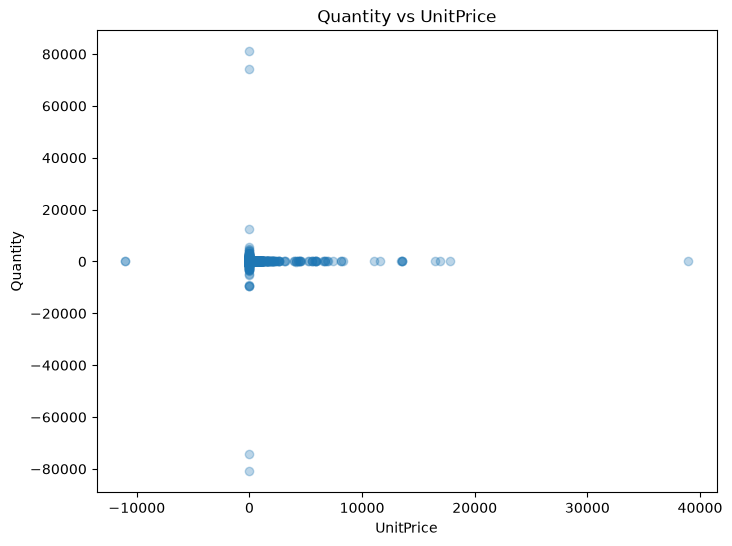

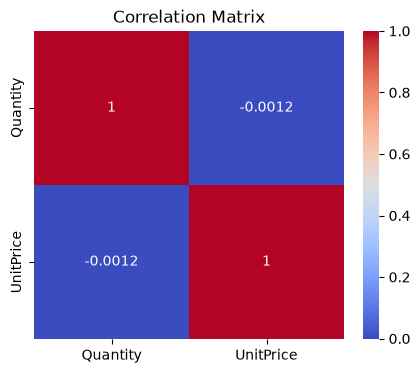

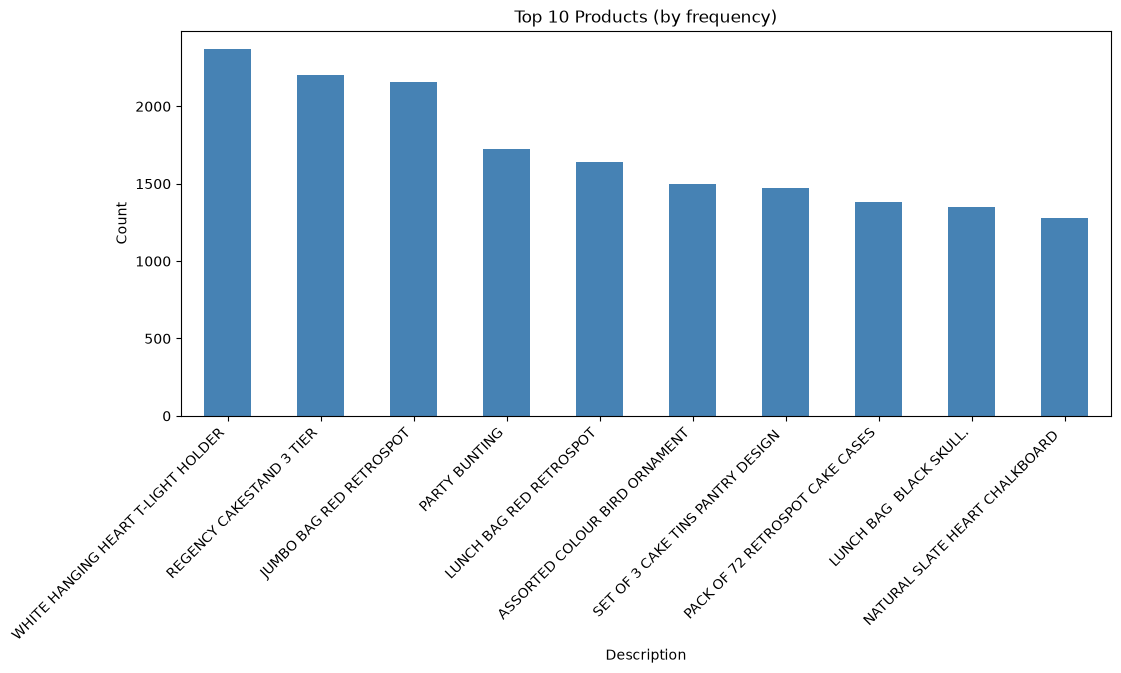

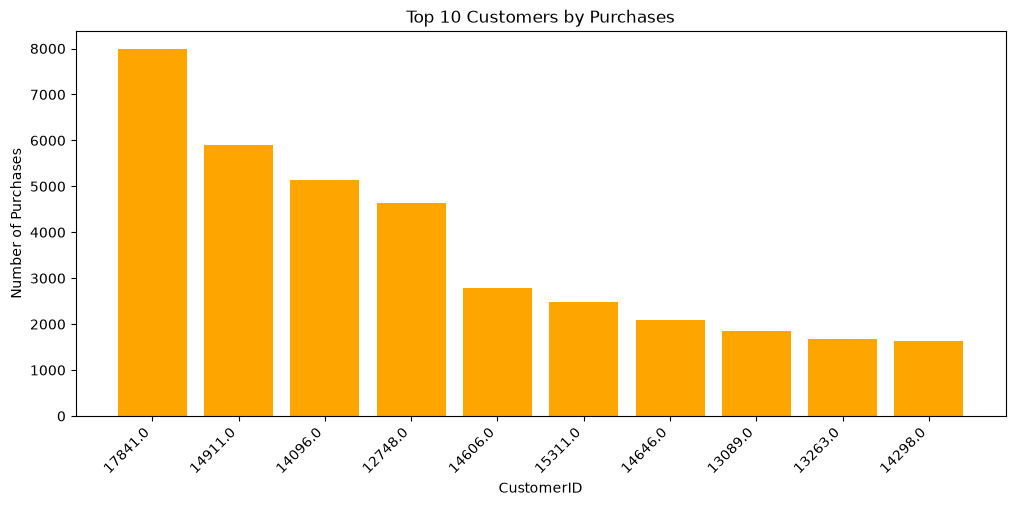


=== IQR OUTLIERS: Quantity ===
Lower bound: -12.5
Upper bound: 23.5
Outliers count: 58619
Outlier %: 10.82%

=== IQR OUTLIERS: UnitPrice ===
Lower bound: -3.0700000000000003
Upper bound: 8.45
Outliers count: 39627
Outlier %: 7.31%


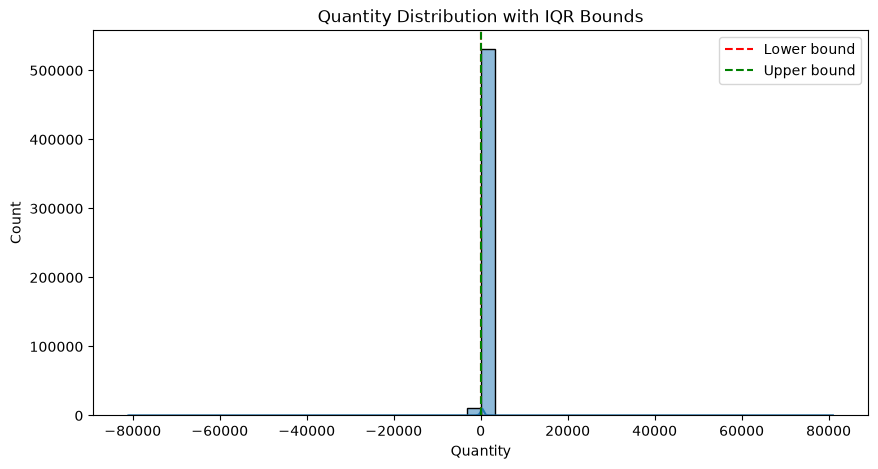

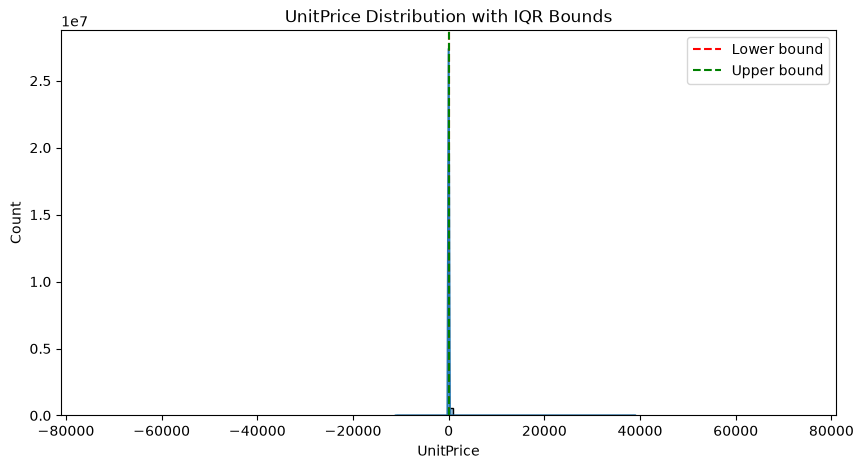

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# =========================
# 2. STATISTICS (mean, median, std)
# =========================
print("\n=== STATISTICS ===")
print(df[["Quantity", "UnitPrice"]].describe().T)

stats = df[["Quantity", "UnitPrice"]].agg([
    "mean", "median", "std", "min", "max"
])
print(stats)

print("\nQuantiles:")
print(df[["Quantity", "UnitPrice"]].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))

# # =========================
# # 3. DISTRIBUTION - QUANTITY
# # =========================
# plt.figure(figsize=(10,5))
# sns.histplot(df["Quantity"], bins=50, kde=True)
# plt.title("Distribution of Quantity")
# plt.xlabel("Quantity")
# plt.ylabel("Frequency")
# plt.show()

# # =========================
# # 4. DISTRIBUTION - UNIT PRICE
# # =========================
# plt.figure(figsize=(10,5))
# sns.histplot(df["UnitPrice"], bins=50, kde=True)
# plt.title("Distribution of UnitPrice")
# plt.xlabel("UnitPrice")
# plt.ylabel("Frequency")
# plt.show()

# =========================
# 5. SCATTER - RELATIONSHIP
# =========================
plt.figure(figsize=(8,6))
plt.scatter(df["UnitPrice"], df["Quantity"], alpha=0.3)
plt.title("Quantity vs UnitPrice")
plt.xlabel("UnitPrice")
plt.ylabel("Quantity")
plt.show()

# =========================
# 6. CORRELATION MATRIX
# =========================
corr = df[["Quantity", "UnitPrice"]].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# =========================
# 7. TOP PRODUCTS
# =========================
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(12,5))
top_products.plot(kind="bar", color="steelblue")
plt.title("Top 10 Products (by frequency)")
plt.xticks(rotation=45,ha='right')
plt.ylabel("Count")
plt.show()

# =========================
# 8. CUSTOMER FREQUENCY
# =========================
customer_freq = df["CustomerID"].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(customer_freq.index.astype(str), customer_freq.values, color="orange")
plt.title("Top 10 Customers by Purchases")
plt.xlabel("CustomerID")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45,ha='right')
plt.show()

# =========================
# 9. IQR OUTLIER DETECTION FUNCTION
# =========================
def detect_iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n=== IQR OUTLIERS: {col} ===")
    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Outliers count: {len(outliers)}")
    print(f"Outlier %: {len(outliers)/len(df)*100:.2f}%")

    return lower, upper, outliers

q_low, q_up, out_q = detect_iqr_outliers(df, "Quantity")
p_low, p_up, out_p = detect_iqr_outliers(df, "UnitPrice")

# =========================
# 10. IQR VISUALIZATION - QUANTITY
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df["Quantity"], bins=50, kde=True)

plt.axvline(q_low, color="red", linestyle="--", label="Lower bound")
plt.axvline(q_up, color="green", linestyle="--", label="Upper bound")

plt.title("Quantity Distribution with IQR Bounds")
plt.legend()
plt.show()

# =========================
# 11. IQR VISUALIZATION - UNIT PRICE
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df["UnitPrice"], bins=50, kde=True)

plt.axvline(p_low, color="red", linestyle="--", label="Lower bound")
plt.axvline(p_up, color="green", linestyle="--", label="Upper bound")

plt.xlim(df["Quantity"].min(), df["Quantity"].max())
# plt.xlim(-100, 200)
plt.title("UnitPrice Distribution with IQR Bounds")
plt.legend()
plt.show()

Correlation Matrix:
Tương quan giữa chính nó (Đường chéo chính): Hệ số tương quan giữa Quantity với Quantity và UnitPrice với UnitPrice đều bằng 1. Điều này là hiển nhiên vì một biến luôn tương quan hoàn hảo với chính nó.

Tương quan giữa Số lượng (Quantity) và Đơn giá (UnitPrice): Hệ số tương quan giữa hai biến này là -0.0012. Hệ số -0.0012 là một con số cực kỳ sát với mức số 0. Dấu âm (-) thể hiện xu hướng nghịch biến (giá tăng thì số lượng giảm), nhưng vì giá trị quá nhỏ (gần như bằng 0) nên xu hướng này yếu đến mức không đáng kể và có thể coi là ngẫu nhiên.
Kết luận: Giữa số lượng sản phẩm được mua (Quantity) và đơn giá của sản phẩm (UnitPrice) gần như không có mối quan hệ tuyến tính nào.
==Quantity Distribution With IQR Bounds======
Dựa trên biểu đồ phân phối số lượng bán ra kèm ranh giới IQR, tập dữ liệu thể hiện các đặc trưng hình học và phân phối thống kê rõ rệt:

-Mức độ tập trung dữ liệu cực kỳ cao (Highly Skewed): Đại đa số các bản ghi (chiếm hơn 500,000 giao dịch) tập trung rất sát dải giá trị quanh mức 0 hoặc các giá trị dương nhỏ. Điều này cho thấy hành vi mua sắm phổ biến của khách hàng là mua sản phẩm với số lượng ít trên mỗi đơn hàng.
-Khoảng biến thiên IQR hẹp: Các đường ranh giới dưới (Lower bound - màu đỏ) và ranh giới trên (Upper bound - màu xanh lá) nằm rất sát nhau và ôm sát vạch số 0. Điều này chứng tỏ khoảng biến thiên của phần lớn dữ liệu gốc rất nhỏ, khiến các giao dịch có số lượng lớn dễ dàng trở thành giá trị ngoại lai.
====Unit Price Distribution With IQR Bound=====
-Mức độ tập trung dữ liệu cực kỳ cao (Highly Skewed): Phần lớn tuyệt đối của dữ liệu (với tần suất - Count lên tới hơn 2.5/ bản ghi) tập trung gần như hoàn toàn tại dải giá trị rất nhỏ quanh mức 0. Biểu đồ chỉ xuất hiện một cột dọc đứng duy nhất ở chính giữa.
-Khoảng biến thiên IQR cực hẹp:** Cả hai đường ranh giới Lower bound (màu đỏ) và Upper bound (màu xanh lá) nằm trùng khít nhau và ép sát vào vạch số 0. Điều này chứng tỏ phần lớn các mặt hàng trong danh mục có đơn giá rất thấp và đồng đều, khiến khoảng biến thiên tứ phân vị (IQR) tiệm cận bằng 0.



In [36]:

# 2. Tiền xử lý dữ liệu (Loại bỏ giá trị âm/lỗi dựa trên phân tích outliers)
df_cleaned = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

# Chuyển đổi InvoiceDate sang datetime và trích xuất năm (Year)
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
df_cleaned['Year'] = df_cleaned['InvoiceDate'].dt.year

# Tính Doanh thu (Revenue) = Quantity * UnitPrice
df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']


# ==========================================
# 1. DOANH THU THEO NĂM
# ==========================================
print("--- DOANH THU THEO TỪNG NĂM ---")
revenue_by_year = df_cleaned.groupby('Year')['Revenue'].sum().reset_index()
# Định dạng hiển thị số tiền dạng chuỗi (thêm dấu phẩy phân tách phần ngàn)
revenue_by_year['Revenue_Formatted'] = revenue_by_year['Revenue'].apply(lambda x: f"{x:,.2f}")
print(revenue_by_year[['Year', 'Revenue_Formatted']])


# ==========================================
# 2. DOANH THU THEO QUỐC GIA (TOP 10)
# ==========================================
print("\n--- TOP 10 QUỐC GIA CÓ DOANH THU CAO NHẤT ---")
revenue_by_country = df_cleaned.groupby('Country')['Revenue'].sum().reset_index()
revenue_by_country = revenue_by_country.sort_values(by='Revenue', ascending=False).reset_index(drop=True)
revenue_by_country['Revenue_Formatted'] = revenue_by_country['Revenue'].apply(lambda x: f"{x:,.2f}")
print(revenue_by_country[['Country', 'Revenue_Formatted']].head(10))


# ==========================================
# 3. DOANH THU THEO NĂM VÀ QUỐC GIA
# ==========================================
print("\n--- BẢNG CHÉO DOANH THU THEO QUỐC GIA QUA CÁC NĂM (TOP 10) ---")
# Sử dụng pivot_table để tạo bảng ma trận giữa Quốc gia và Năm
revenue_matrix = df_cleaned.pivot_table(
    values='Revenue', 
    index='Country', 
    columns='Year', 
    aggfunc='sum', 
    fill_value=0
)

# Sắp xếp theo tổng doanh thu mọi năm để lấy ra những nước lớn nhất
revenue_matrix['Total'] = revenue_matrix.sum(axis=1)
revenue_matrix = revenue_matrix.sort_values(by='Total', ascending=False).drop(columns='Total')

# Định dạng các cột số tiền 
revenue_matrix_formatted = revenue_matrix.head(10).map(lambda x: f"{x:,.2f}")
print(revenue_matrix_formatted)

--- DOANH THU THEO TỪNG NĂM ---
   Year Revenue_Formatted
0  2010        823,746.14
1  2011      9,842,938.40

--- TOP 10 QUỐC GIA CÓ DOANH THU CAO NHẤT ---
          Country Revenue_Formatted
0  United Kingdom      9,025,222.08
1     Netherlands        285,446.34
2            EIRE        283,453.96
3         Germany        228,867.14
4          France        209,715.11
5       Australia        138,521.31
6           Spain         61,577.11
7     Switzerland         57,089.90
8         Belgium         41,196.34
9          Sweden         38,378.33

--- BẢNG CHÉO DOANH THU THEO QUỐC GIA QUA CÁC NĂM (TOP 10) ---
Year                  2010          2011
Country                                 
United Kingdom  748,268.98  8,276,953.10
Netherlands       8,784.48    276,661.86
EIRE             10,033.26    273,420.70
Germany          15,241.14    213,626.00
France            9,616.31    200,098.80
Australia         1,032.85    137,488.46
Spain             1,843.73     59,733.38
Switzerland   

In [38]:
print("==================================================")
print("       BÁO CÁO TỔNG QUAN CHẤT LƯỢNG DỮ LIỆU       ")
print("==================================================")

# --- 1. SỐ DÒNG DỮ LIỆU TRÙNG LẶP ---
num_duplicates = df.duplicated().sum()
pct_duplicates = (num_duplicates / len(df)) * 100
print(f"1. Số dòng dữ liệu trùng lặp hoàn toàn: {num_duplicates:,} dòng ({pct_duplicates:.2f}%)")

# --- 2. SỐ DÒNG DỮ LIỆU THIẾU THÔNG TIN (MISSING VALUES) ---
print("\n2. Số dòng thiếu thông tin (Null/NaN) theo từng cột:")
missing_info = df.isnull().sum()
for col, missing_count in missing_info.items():
    if missing_count > 0:
        pct_missing = (missing_count / len(df)) * 100
        print(f"   - Cột [{col}]: {missing_count:,} dòng thiếu ({pct_missing:.2f}%)")
if missing_info.sum() == 0:
    print("   -> Tuyệt vời! Không có cột nào bị thiếu dữ liệu.")

# --- 3. SỐ DÒNG CÓ SỐ LƯỢNG HOẶC ĐƠN GIÁ < 0 ---
invalid_quantity = (df['Quantity'] < 0).sum()
invalid_price = (df['UnitPrice'] < 0).sum()
# Tổng số dòng có Quantity <0 hoặc UnitPrice <0 
invalid_both = ((df['Quantity'] < 0) | (df['UnitPrice'] < 0)).sum()

print("\n3. Thống kê dữ liệu có giá trị âm (< 0):")
print(f"   - Số dòng có Quantity < 0  : {invalid_quantity:,} dòng")
print(f"   - Số dòng có UnitPrice < 0 : {invalid_price:,} dòng")
print(f"   - Tổng số dòng bị âm (hoặc Quantity hoặc UnitPrice < 0): {invalid_both:,} dòng")
print("==================================================")

       BÁO CÁO TỔNG QUAN CHẤT LƯỢNG DỮ LIỆU       
1. Số dòng dữ liệu trùng lặp hoàn toàn: 5,268 dòng (0.97%)

2. Số dòng thiếu thông tin (Null/NaN) theo từng cột:
   - Cột [Description]: 1,454 dòng thiếu (0.27%)
   - Cột [CustomerID]: 135,080 dòng thiếu (24.93%)

3. Thống kê dữ liệu có giá trị âm (< 0):
   - Số dòng có Quantity < 0  : 10,624 dòng
   - Số dòng có UnitPrice < 0 : 2 dòng
   - Tổng số dòng bị âm (hoặc Quantity hoặc UnitPrice < 0): 10,626 dòng


Người 2: Tiền xử lý: Xử lý DL thiếu (trường nào bị thiếu thuộc tính thì xóa), DL nhiễu( sai lệch), drop hàng thừa, encoding (chuyển tất cả cột về dạng số), scaling

Tiền xử lý xong lưu file vô 
../data/processed/online_retail_cleaned.csv